In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print("Missing values in each column:\n")

missing_values = df.isnull().sum()

print(missing_values)

Missing values in each column:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# Make a copy so that the original dataset remains unchanged
data = df.copy()

# Fill missing Age values using median
data['Age'] = data['Age'].fillna(data['Age'].median())

# Fill missing Embarked values using the most frequent value
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Cabin has too many missing values.
# We will convert Cabin information into a simpler feature later.
data['Cabin'] = data['Cabin'].fillna('Unknown')

print("Missing values after basic cleaning:\n")
print(data.isnull().sum())

Missing values after basic cleaning:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [7]:
baseline_data = data.copy()

print("Baseline dataset shape:", baseline_data.shape)

baseline_data.head()

Baseline dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [8]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

print("FamilySize feature created!")

data[['SibSp', 'Parch', 'FamilySize']].head(10)

FamilySize feature created!


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [9]:
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

print("IsAlone feature created!")

data[['FamilySize', 'IsAlone']].head(10)

IsAlone feature created!


,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [10]:
data['FarePerPerson'] = data['Fare'] / data['FamilySize']

print("FarePerPerson feature created!")

data[['Fare', 'FamilySize', 'FarePerPerson']].head(10)

FarePerPerson feature created!


,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000
5,8.4583,1,8.45830
6,51.8625,1,51.86250
7,21.0750,5,4.21500
8,11.1333,3,3.71110
9,30.0708,2,15.03540


In [11]:
age_bins = [0, 12, 18, 35, 60, 100]

age_labels = [
    'Child',
    'Teenager',
    'Young Adult',
    'Adult',
    'Senior'
]

data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

print("AgeGroup feature created!")

data[['Age', 'AgeGroup']].head(20)

AgeGroup feature created!


,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager


In [12]:
def family_category(size):

    if size == 1:
        return 'Alone'

    elif size <= 4:
        return 'Small Family'

    elif size <= 7:
        return 'Medium Family'

    else:
        return 'Large Family'


data['FamilyCategory'] = data['FamilySize'].apply(family_category)

print("FamilyCategory feature created!")

data[['FamilySize', 'FamilyCategory']].head(20)

FamilyCategory feature created!


,FamilySize,FamilyCategory
0,2,Small Family
1,2,Small Family
2,1,Alone
3,2,Small Family
4,1,Alone
5,1,Alone
6,1,Alone
7,5,Medium Family
8,3,Small Family
9,2,Small Family


In [13]:
data['Sex_Pclass'] = data['Sex'].astype(str) + "_" + data['Pclass'].astype(str)

print("Interaction feature created!")

data[['Sex', 'Pclass', 'Sex_Pclass']].head(20)

Interaction feature created!


,Sex,Pclass,Sex_Pclass
0,male,3,male_3
1,female,1,female_1
2,female,3,female_3
3,female,1,female_1
4,male,3,male_3
5,male,3,male_3
6,male,1,male_1
7,male,3,male_3
8,female,3,female_3
9,female,2,female_2


In [14]:
data['VoyageDate'] = pd.to_datetime('1912-04-10')

print("VoyageDate created!")

data[['VoyageDate']].head()

VoyageDate created!


,VoyageDate
0,1912-04-10
1,1912-04-10
2,1912-04-10
3,1912-04-10
4,1912-04-10


In [15]:
data['VoyageYear'] = data['VoyageDate'].dt.year

data['VoyageMonth'] = data['VoyageDate'].dt.month

data['VoyageDay'] = data['VoyageDate'].dt.day

data['VoyageDayOfWeek'] = data['VoyageDate'].dt.dayofweek

print("Date decomposition completed!")

data[
    [
        'VoyageDate',
        'VoyageYear',
        'VoyageMonth',
        'VoyageDay',
        'VoyageDayOfWeek'
    ]
].head()

Date decomposition completed!


,VoyageDate,VoyageYear,VoyageMonth,VoyageDay,VoyageDayOfWeek
0,1912-04-10,1912,4,10,2
1,1912-04-10,1912,4,10,2
2,1912-04-10,1912,4,10,2
3,1912-04-10,1912,4,10,2
4,1912-04-10,1912,4,10,2


In [16]:
engineered_features = [
    'FamilySize',
    'IsAlone',
    'FarePerPerson',
    'AgeGroup',
    'FamilyCategory',
    'Sex_Pclass',
    'VoyageYear',
    'VoyageMonth',
    'VoyageDay',
    'VoyageDayOfWeek'
]

print("Engineered Features:\n")

for feature in engineered_features:
    print("-", feature)

Engineered Features:

- FamilySize
- IsAlone
- FarePerPerson
- AgeGroup
- FamilyCategory
- Sex_Pclass
- VoyageYear
- VoyageMonth
- VoyageDay
- VoyageDayOfWeek


In [17]:
print("Updated dataset shape:", data.shape)

data.head()

Updated dataset shape: (891, 23)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,FarePerPerson,AgeGroup,FamilyCategory,Sex_Pclass,VoyageDate,VoyageYear,VoyageMonth,VoyageDay,VoyageDayOfWeek
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,2,0,3.62500,Young Adult,Small Family,male_3,1912-04-10,1912,4,10,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,35.64165,Adult,Small Family,female_1,1912-04-10,1912,4,10,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,1,1,7.92500,Young Adult,Alone,female_3,1912-04-10,1912,4,10,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,26.55000,Young Adult,Small Family,female_1,1912-04-10,1912,4,10,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,1,1,8.05000,Young Adult,Alone,male_3,1912-04-10,1912,4,10,2


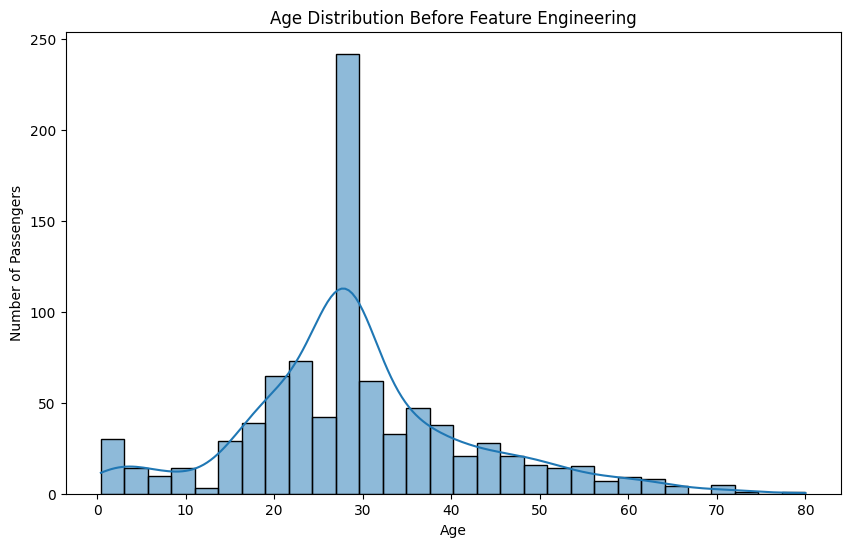

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    baseline_data['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution Before Feature Engineering")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")

plt.show()

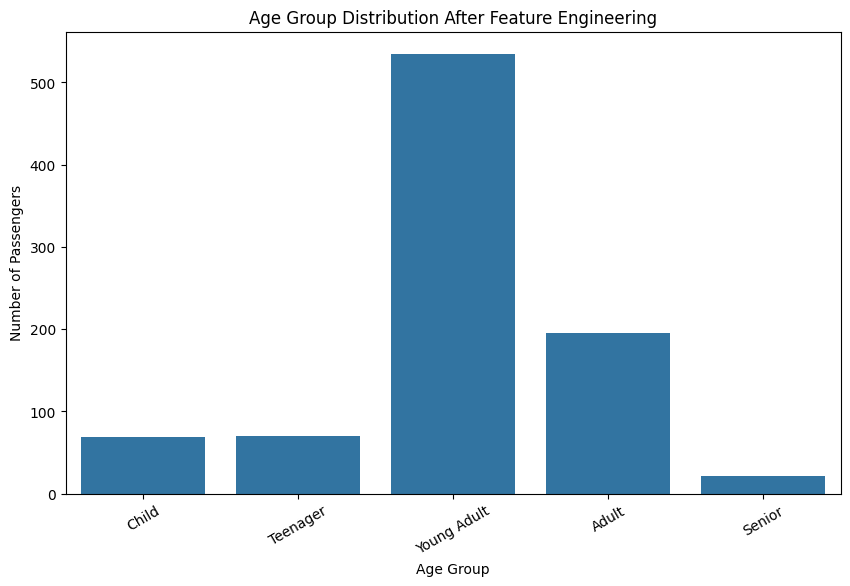

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=data,
    x='AgeGroup',
    order=age_labels
)

plt.title("Age Group Distribution After Feature Engineering")

plt.xlabel("Age Group")

plt.ylabel("Number of Passengers")

plt.xticks(rotation=30)

plt.show()

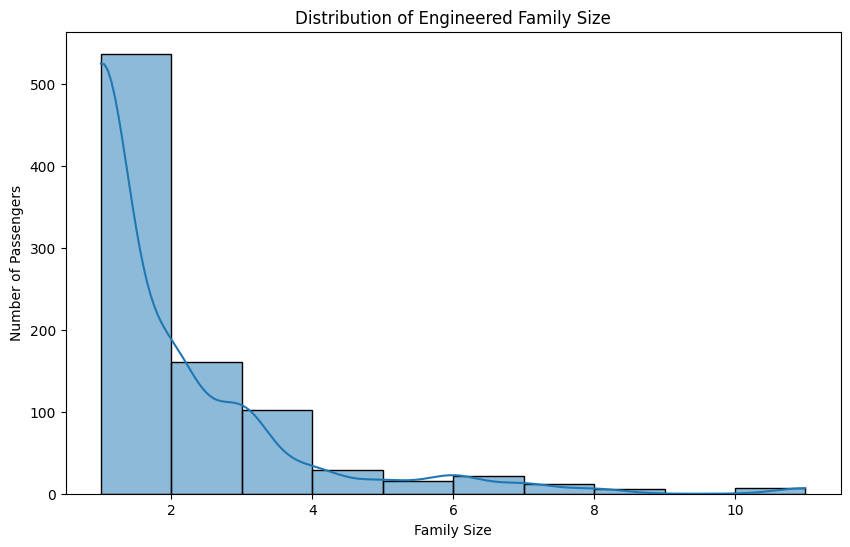

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data['FamilySize'],
    bins=10,
    kde=True
)

plt.title("Distribution of Engineered Family Size")

plt.xlabel("Family Size")

plt.ylabel("Number of Passengers")

plt.show()

AgeGroup
Child          0.579710
Teenager       0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


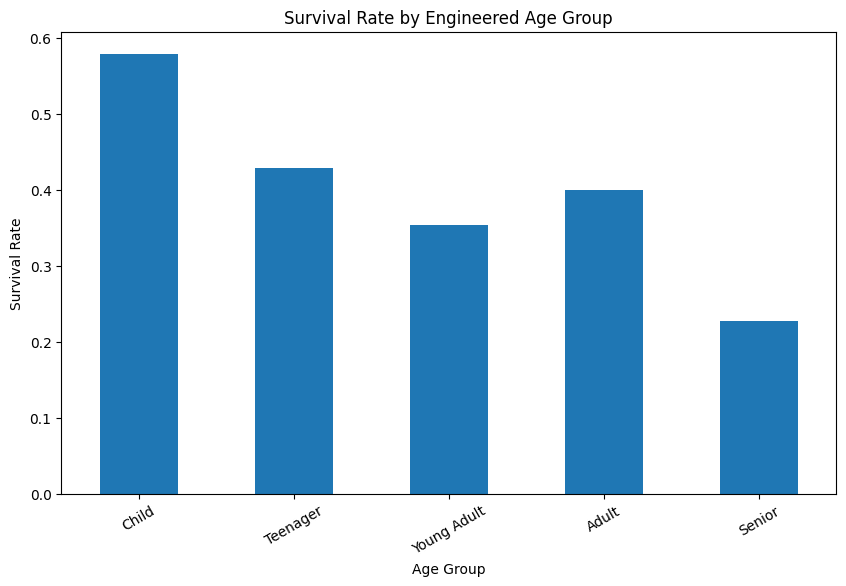

In [21]:
survival_by_age = data.groupby(
    'AgeGroup',
    observed=False
)['Survived'].mean()

print(survival_by_age)

plt.figure(figsize=(10, 6))

survival_by_age.plot(
    kind='bar'
)

plt.title("Survival Rate by Engineered Age Group")

plt.xlabel("Age Group")

plt.ylabel("Survival Rate")

plt.xticks(rotation=30)

plt.show()

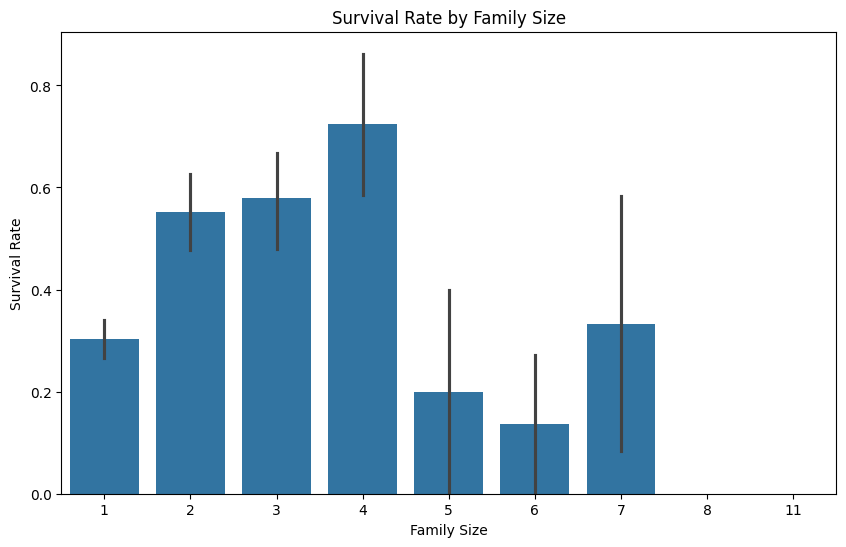

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x='FamilySize',
    y='Survived'
)

plt.title("Survival Rate by Family Size")

plt.xlabel("Family Size")

plt.ylabel("Survival Rate")

plt.show()

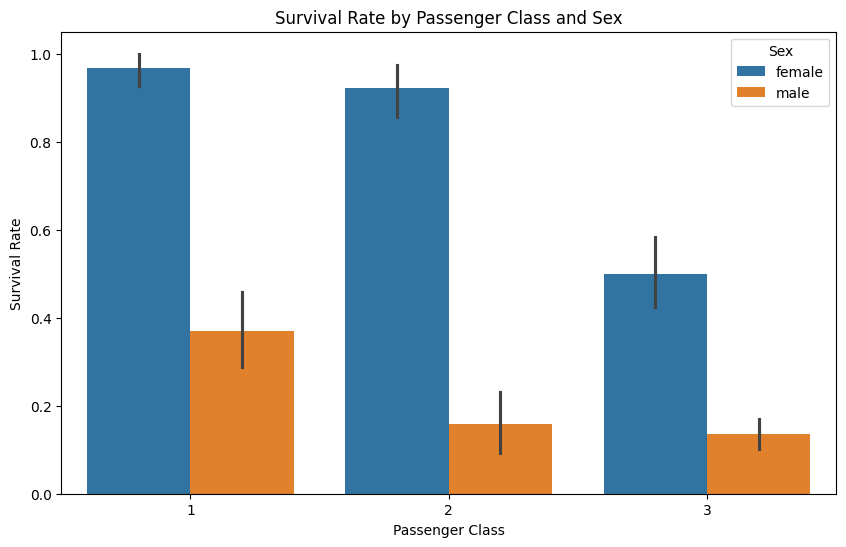

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x='Pclass',
    y='Survived',
    hue='Sex'
)

plt.title("Survival Rate by Passenger Class and Sex")

plt.xlabel("Passenger Class")

plt.ylabel("Survival Rate")

plt.show()

In [24]:
baseline_features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X_baseline = baseline_data[baseline_features]

y = baseline_data['Survived']

print("Baseline features:")
print(baseline_features)

Baseline features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [25]:
X_baseline = pd.get_dummies(
    X_baseline,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

print("Encoded baseline data:")

X_baseline.head()

Encoded baseline data:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [26]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train_base.shape[0])

print("Testing samples:", X_test_base.shape[0])

Training samples: 712
Testing samples: 179


In [27]:
baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

baseline_model.fit(
    X_train_base,
    y_train
)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [28]:
baseline_predictions = baseline_model.predict(X_test_base)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

print("BASELINE MODEL PERFORMANCE")
print("--------------------------------")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

BASELINE MODEL PERFORMANCE
--------------------------------
Accuracy : 0.8101
Precision: 0.7778
Recall   : 0.7101
F1 Score : 0.7424


In [29]:
engineered_features_for_model = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',

    # Engineered features
    'FamilySize',
    'IsAlone',
    'FarePerPerson',
    'AgeGroup',
    'FamilyCategory',
    'Sex_Pclass'
]

X_engineered = data[engineered_features_for_model]

print("Engineered dataset prepared!")
print(X_engineered.head())

Engineered dataset prepared!
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  IsAlone  \
0       3    male  22.0      1      0   7.2500        S           2        0   
1       1  female  38.0      1      0  71.2833        C           2        0   
2       3  female  26.0      0      0   7.9250        S           1        1   
3       1  female  35.0      1      0  53.1000        S           2        0   
4       3    male  35.0      0      0   8.0500        S           1        1   

   FarePerPerson     AgeGroup FamilyCategory Sex_Pclass  
0        3.62500  Young Adult   Small Family     male_3  
1       35.64165        Adult   Small Family   female_1  
2        7.92500  Young Adult          Alone   female_3  
3       26.55000  Young Adult   Small Family   female_1  
4        8.05000  Young Adult          Alone     male_3  


In [30]:
X_engineered = pd.get_dummies(
    X_engineered,
    columns=[
        'Sex',
        'Embarked',
        'AgeGroup',
        'FamilyCategory',
        'Sex_Pclass'
    ],
    drop_first=True
)

print("Encoded engineered dataset:")

X_engineered.head()

Encoded engineered dataset:


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Sex_male,Embarked_Q,Embarked_S,AgeGroup_Teenager,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FamilyCategory_Large Family,FamilyCategory_Medium Family,FamilyCategory_Small Family,Sex_Pclass_female_2,Sex_Pclass_female_3,Sex_Pclass_male_1,Sex_Pclass_male_2,Sex_Pclass_male_3
0,3,22.0,1,0,7.2500,2,0,3.62500,True,False,True,False,True,False,False,False,False,True,False,False,False,False,True
1,1,38.0,1,0,71.2833,2,0,35.64165,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,3,26.0,0,0,7.9250,1,1,7.92500,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False
3,1,35.0,1,0,53.1000,2,0,26.55000,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,3,35.0,0,0,8.0500,1,1,8.05000,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True


In [31]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train_eng.shape[0])

print("Testing samples:", X_test_eng.shape[0])

Training samples: 712
Testing samples: 179


In [32]:
engineered_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

engineered_model.fit(
    X_train_eng,
    y_train_eng
)

print("Engineered model trained successfully!")

Engineered model trained successfully!


In [33]:
engineered_predictions = engineered_model.predict(
    X_test_eng
)

engineered_accuracy = accuracy_score(
    y_test_eng,
    engineered_predictions
)

engineered_precision = precision_score(
    y_test_eng,
    engineered_predictions
)

engineered_recall = recall_score(
    y_test_eng,
    engineered_predictions
)

engineered_f1 = f1_score(
    y_test_eng,
    engineered_predictions
)

print("ENGINEERED MODEL PERFORMANCE")
print("--------------------------------")
print("Accuracy :", round(engineered_accuracy, 4))
print("Precision:", round(engineered_precision, 4))
print("Recall   :", round(engineered_recall, 4))
print("F1 Score :", round(engineered_f1, 4))

ENGINEERED MODEL PERFORMANCE
--------------------------------
Accuracy : 0.8045
Precision: 0.75
Recall   : 0.7391
F1 Score : 0.7445


In [34]:
comparison = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Before Feature Engineering': [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    'After Feature Engineering': [
        engineered_accuracy,
        engineered_precision,
        engineered_recall,
        engineered_f1
    ]
})

comparison

,Metric,Before Feature Engineering,After Feature Engineering
0,Accuracy,0.810056,0.804469
1,Precision,0.777778,0.750000
2,Recall,0.710145,0.739130
3,F1 Score,0.742424,0.744526


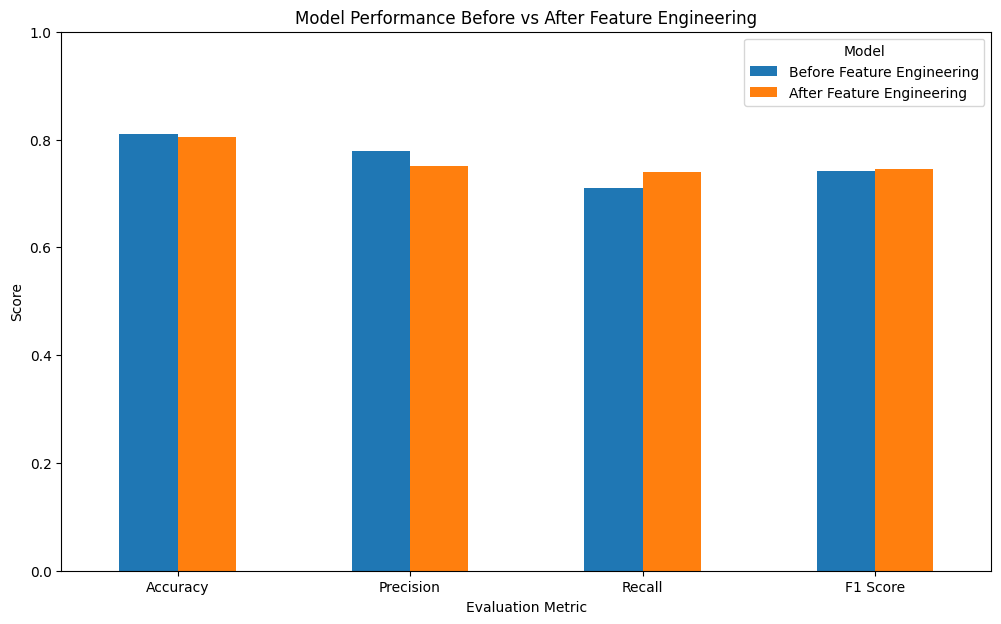

In [35]:
comparison_plot = comparison.set_index('Metric')

comparison_plot.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title("Model Performance Before vs After Feature Engineering")

plt.xlabel("Evaluation Metric")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Model"
)

plt.show()

In [36]:
accuracy_improvement = (
    engineered_accuracy - baseline_accuracy
) * 100

f1_improvement = (
    engineered_f1 - baseline_f1
) * 100

print(
    "Accuracy improvement:",
    round(accuracy_improvement, 2),
    "%"
)

print(
    "F1-score improvement:",
    round(f1_improvement, 2),
    "%"
)

Accuracy improvement: -0.56 %
F1-score improvement: 0.21 %


In [37]:
importance = pd.DataFrame({

    'Feature': X_engineered.columns,

    'Importance': engineered_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
1,Age,0.176577
7,FarePerPerson,0.158522
8,Sex_male,0.154255
4,Fare,0.153111
22,Sex_Pclass_male_3,0.042608
0,Pclass,0.040923
18,Sex_Pclass_female_2,0.036261
5,FamilySize,0.031272
19,Sex_Pclass_female_3,0.023673
10,Embarked_S,0.023598


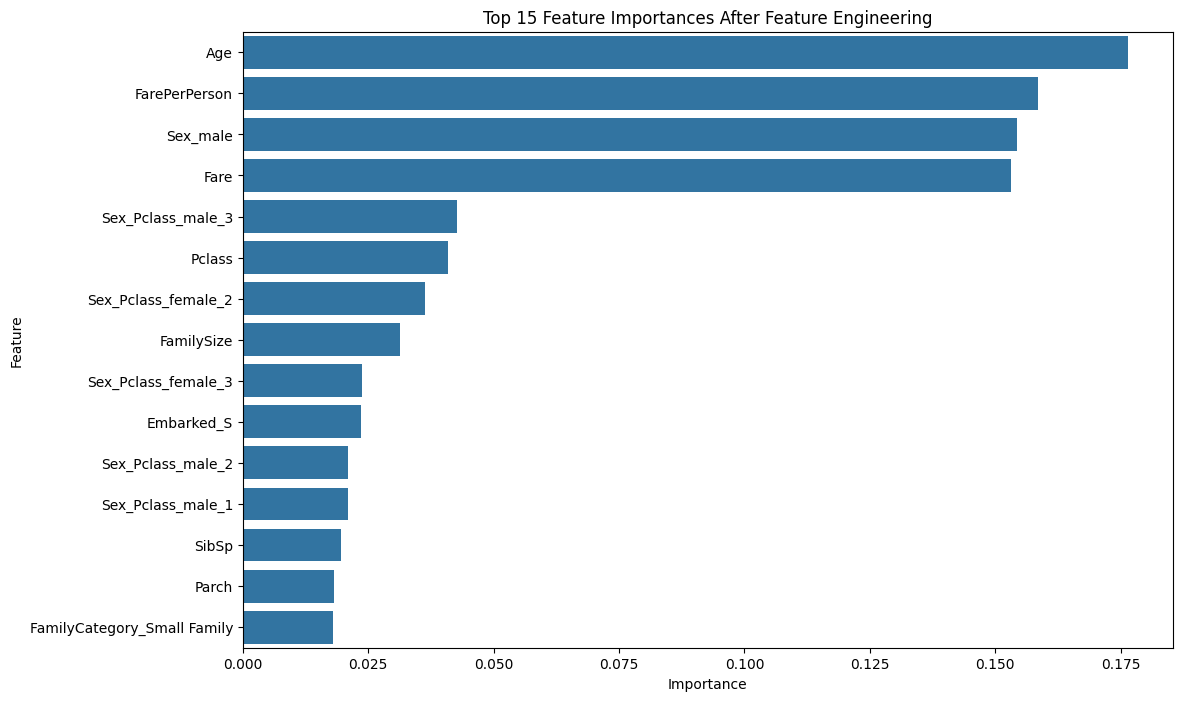

In [38]:
top_features = importance.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 15 Feature Importances After Feature Engineering"
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

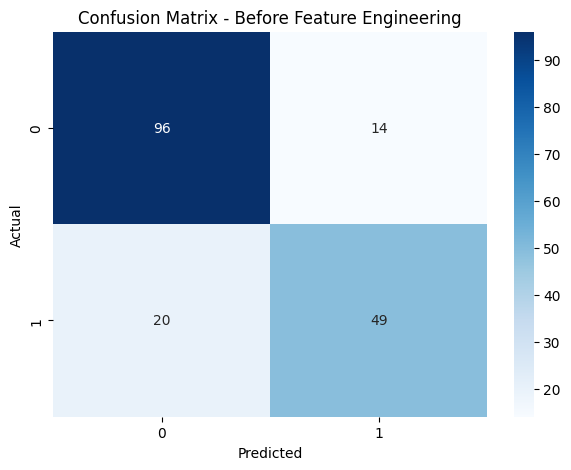

In [39]:
cm_baseline = confusion_matrix(
    y_test,
    baseline_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix - Before Feature Engineering"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

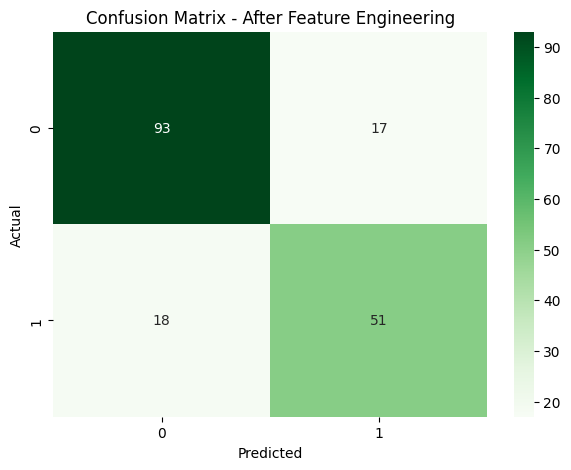

In [40]:
cm_engineered = confusion_matrix(
    y_test_eng,
    engineered_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_engineered,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Confusion Matrix - After Feature Engineering"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [41]:
print("Classification Report - After Feature Engineering")
print("====================================================")

print(
    classification_report(
        y_test_eng,
        engineered_predictions
    )
)

Classification Report - After Feature Engineering
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



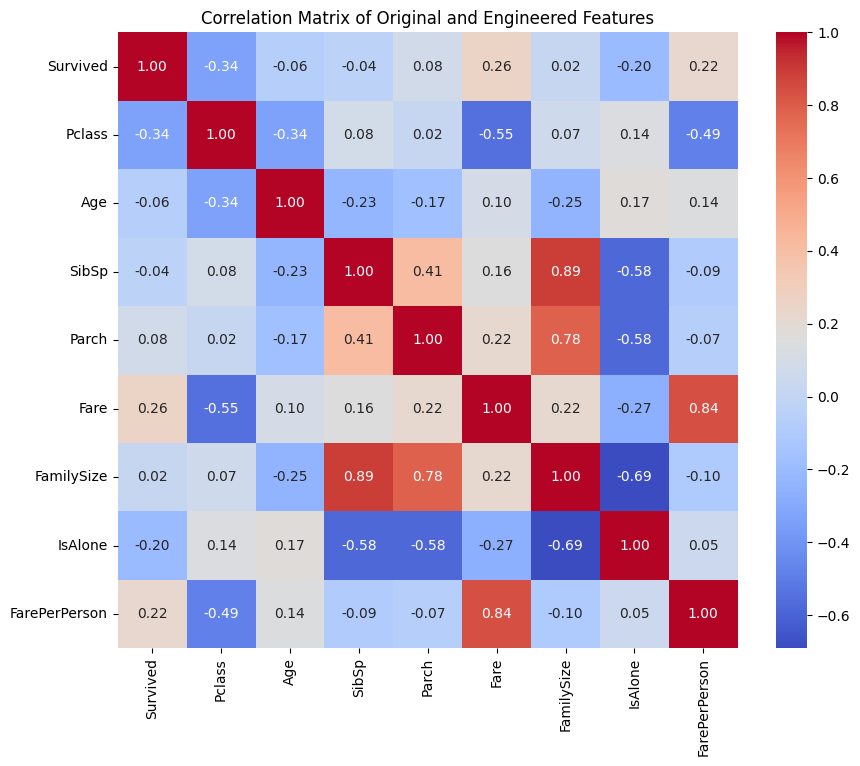

In [42]:
numeric_columns = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone',
    'FarePerPerson'
]

correlation = data[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix of Original and Engineered Features"
)

plt.show()

In [43]:
importance_table = importance.copy()

importance_table['Importance (%)'] = (
    importance_table['Importance'] * 100
)

importance_table = importance_table[
    ['Feature', 'Importance (%)']
]

importance_table.head(15)

,Feature,Importance (%)
1,Age,17.657678
7,FarePerPerson,15.852169
8,Sex_male,15.425465
4,Fare,15.311143
22,Sex_Pclass_male_3,4.260819
0,Pclass,4.092327
18,Sex_Pclass_female_2,3.626112
5,FamilySize,3.127182
19,Sex_Pclass_female_3,2.367266
10,Embarked_S,2.359808


In [44]:
comparison.to_csv(
    'model_comparison.csv',
    index=False
)

importance_table.to_csv(
    'feature_importance.csv',
    index=False
)

data.to_csv(
    'feature_engineered_titanic.csv',
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [45]:
print("=" * 60)
print("FEATURE ENGINEERING PROJECT - FINAL RESULTS")
print("=" * 60)

print("\n1. Dataset")
print("Titanic Passenger Dataset")

print("\n2. Engineered Features")
for feature in engineered_features:
    print("   -", feature)

print("\n3. Model Used")
print("Random Forest Classifier")

print("\n4. Baseline Accuracy:")
print(round(baseline_accuracy, 4))

print("\n5. Engineered Model Accuracy:")
print(round(engineered_accuracy, 4))

print("\n6. Accuracy Improvement:")
print(round(accuracy_improvement, 2), "%")

print("\n7. Baseline F1 Score:")
print(round(baseline_f1, 4))

print("\n8. Engineered F1 Score:")
print(round(engineered_f1, 4))

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

FEATURE ENGINEERING PROJECT - FINAL RESULTS

1. Dataset
Titanic Passenger Dataset

2. Engineered Features
   - FamilySize
   - IsAlone
   - FarePerPerson
   - AgeGroup
   - FamilyCategory
   - Sex_Pclass
   - VoyageYear
   - VoyageMonth
   - VoyageDay
   - VoyageDayOfWeek

3. Model Used
Random Forest Classifier

4. Baseline Accuracy:
0.8101

5. Engineered Model Accuracy:
0.8045

6. Accuracy Improvement:
-0.56 %

7. Baseline F1 Score:
0.7424

8. Engineered F1 Score:
0.7445

PROJECT COMPLETED SUCCESSFULLY!
